In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


df = pd.read_csv('automobile_dataset.csv')
print(df.head())

            Make   Model  Year Fuel_Type Transmission  Engine_Size  Mileage  \
0  Mercedes-Benz     GLE  2024    Petrol    Automatic          2.3      100   
1        Hyundai  Tucson  2008    Petrol    Automatic          2.3   387035   
2     Volkswagen    Golf  2021    Hybrid          NaN          1.9    46054   
3      Chevrolet   Tahoe  2005    Petrol          NaN          2.2   141302   
4         Toyota   Camry  2022    Petrol    Automatic          1.9    32813   

   Horsepower  Torque  Owners  Accident_History  Service_History   Color  \
0       186.0   196.0       1               0.0              NaN  Silver   
1       189.0   190.0       4               0.0              NaN    Blue   
2       158.0   153.0       1               0.0  Partial Service    Gray   
3       169.0   165.0       5               1.0       No Service    Blue   
4       149.0   141.0       1               0.0     Full Service   Brown   

   Body_Type Drivetrain  Fuel_Efficiency Location  Selling_Price  
0

In [10]:
#simple linear regression
X = df[['Year']]
y = df['Selling_Price']

print(X.shape)
print(y.shape)


(5500, 1)
(5500,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("num of data train:", X_train.shape[0])
print("num of data test:", X_test.shape[0])

num of data train: 4400
num of data test: 1100


In [12]:
model_simple = LinearRegression()

model_simple.fit(X_train, y_train)

print("Slope (a):", model_simple.coef_[0])
print("Intercept (b):", model_simple.intercept_)

Slope (a): 1759.1324245341345
Intercept (b): -3531438.33577354


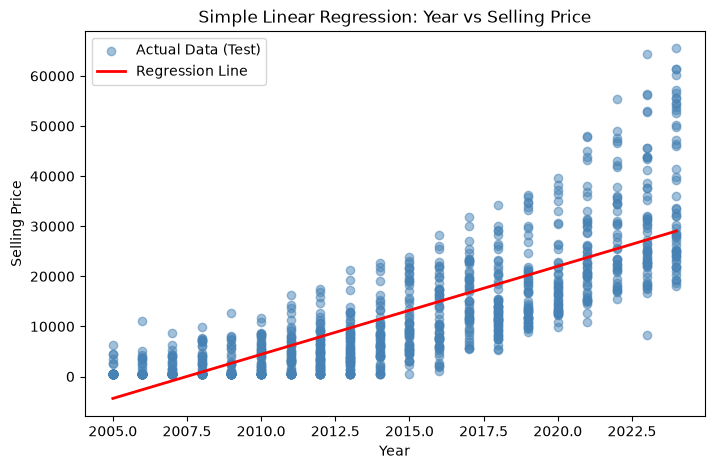

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(X_test, y_test, color='steelblue', alpha=0.5, label='Actual Data (Test)')

X_test_sorted = X_test.sort_values(by='Year')
y_pred_sorted = model_simple.predict(X_test_sorted)

plt.plot(X_test_sorted, y_pred_sorted, color='red', linewidth=2, label='Regression Line')

plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.title('Simple Linear Regression: Year vs Selling Price')
plt.legend()
plt.show()

In [ ]:
#multiple linear regression
features = ['Year', 'Engine_Size', 'Mileage', 'Horsepower', 'Torque', 'Owners', 'Accident_History', 'Fuel_Efficiency']

X_multi = df[features]
y_multi = df['Selling_Price']

print("Shape X:", X_multi.shape)
print("\namout missing value each feature:\n")
print(X_multi.isnull().sum())

Shape ของ X: (5500, 8)

amout missing value each feature:

Year                  0
Engine_Size         844
Mileage               0
Horsepower          800
Torque              799
Owners                0
Accident_History    812
Fuel_Efficiency     794
dtype: int64
